# Conditional gradient methods
Implement the Frank-Wolfe algorithm in Python to solve the projection problem

Достигнуто максимальное число итераций (200).


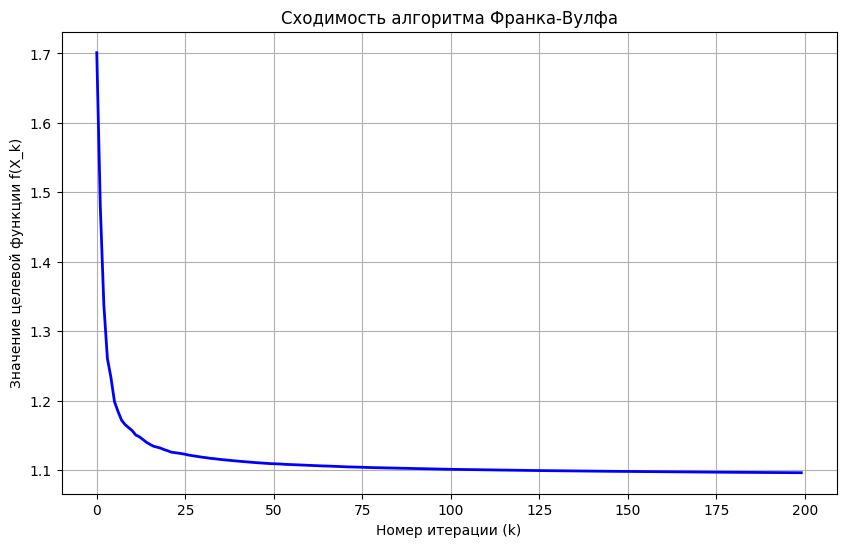


Проверка условий для X_proj:
1. Неотрицательные элементы: True
2. Суммы по строкам: [1. 1. 1. 1. 1.]
3. Суммы по столбцам: [1. 1. 1. 1. 1.]


In [1]:
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

def project_to_birkhoff_frank_wolfe(Y, max_iter=100, tol=1e-6):

    n = Y.shape[0]
    assert Y.shape[0] == Y.shape[1],

    Xk = np.ones((n, n)) / n

    objective_history = []

    for k in range(max_iter):

        obj_val = 0.5 * np.linalg.norm(Xk - Y, 'fro')**2
        objective_history.append(obj_val)


        if k > 0 and abs(objective_history[-1] - objective_history[-2]) < tol:
            print(f"Сошлось после {k} итераций.")
            break


        grad_fk = Xk - Y


        row_ind, col_ind = linear_sum_assignment(grad_fk)
        Sk = np.zeros((n, n))
        Sk[row_ind, col_ind] = 1

        #  gamma_k
        delta_k = Xk - Sk
        denom = np.linalg.norm(delta_k, 'fro')**2
        if denom < 1e-12:
            gamma_k = 0.0
        else:
            gamma_k = np.sum((Xk - Y) * delta_k) / denom
            gamma_k = np.clip(gamma_k, 0.0, 1.0)


        Xk = (1 - gamma_k) * Xk + gamma_k * Sk

    else:
        print(f"Достигнуто максимальное число итераций ({max_iter}).")

    return Xk, objective_history

# n=5
np.random.seed(42)
n = 5
Y = np.random.rand(n, n)

# 200 итераций
X_proj, history = project_to_birkhoff_frank_wolfe(Y, max_iter=200)


plt.figure(figsize=(10, 6))
plt.plot(history, 'b-', linewidth=2)
plt.xlabel('Номер итерации (k)')
plt.ylabel('Значение целевой функции f(X_k)')
plt.title('Сходимость алгоритма Франка-Вулфа')
plt.grid(True)
plt.show()

print("\nПроверка условий для X_proj:")
print("1. Неотрицательные элементы:", np.all(X_proj >= 0))
print("2. Суммы по строкам:", np.sum(X_proj, axis=1))
print("3. Суммы по столбцам:", np.sum(X_proj, axis=0))

# Subgradient method
Finding a point in the intersection of convex sets.

Сходимость достигнута на итерации 0


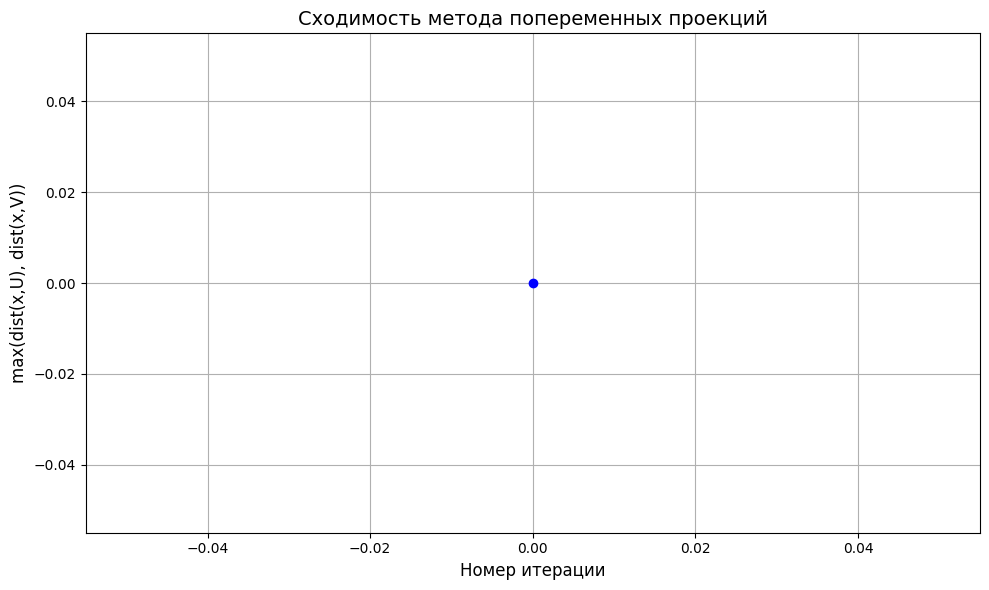


Результаты:
Начальная точка: [2 1]
Оптимальная точка: [2 1]
‖A¹ᐟ²(x-y)‖₂ = 1.000000 (≤ 1)
‖Σx‖∞ = 1.000000 (≤ 1)


In [22]:

import numpy as np
import matplotlib.pyplot as plt

#
n = 2
y = np.array([3, 2])
sigma = np.array([0.5, 1])
Sigma = np.diag(sigma)
A = np.array([[1, 0], [-1, 1]])
x0 = np.array([2, 1])

A_sym = (A + A.T) / 2

eigvals, eigvecs = np.linalg.eigh(A_sym)
eigvals = np.clip(eigvals, a_min=1e-8, a_max=None)
A_sqrt = eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T

# Метод попеременных проекций
def alternating_projections(A_sqrt, Sigma, y, x0, max_iter=100, tol=1e-6):
    x = x0.copy()
    history = []

    for k in range(max_iter):
        # Проекция на U
        diff = x - y
        norm = np.linalg.norm(A_sqrt @ diff)
        if norm > 1:
            x_proj_U = y + (diff / norm)
        else:
            x_proj_U = x.copy()

        # Проекция на V
        sigma_x = Sigma @ x_proj_U
        sigma_x_clipped = np.clip(sigma_x, -1, 1)
        x_proj_V = np.linalg.solve(Sigma, sigma_x_clipped)

        x_new = x_proj_V
        dist_U = max(0, np.linalg.norm(A_sqrt @ (x_new - y)) - 1)
        dist_V = max(0, np.max(np.abs(Sigma @ x_new)) - 1)
        history.append(max(dist_U, dist_V))

        if np.linalg.norm(x_new - x) < tol:
            print(f"Сходимость достигнута на итерации {k}")
            break

        x = x_new

    return x, history


x_opt, obj_history = alternating_projections(A_sqrt, Sigma, y, x0, max_iter=200)

plt.figure(figsize=(10, 6))
plt.plot(range(len(obj_history)), obj_history, marker='o', color='blue', linewidth=2)
plt.xlabel('Номер итерации', fontsize=12)
plt.ylabel('max(dist(x,U), dist(x,V))', fontsize=12)
plt.title('Сходимость метода попеременных проекций', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nРезультаты:")
print(f"Начальная точка: {x0}")
print(f"Оптимальная точка: {x_opt}")
print(f"‖A¹ᐟ²(x-y)‖₂ = {np.linalg.norm(A_sqrt @ (x_opt - y)):.6f} (≤ 1)")
print(f"‖Σx‖∞ = {np.max(np.abs(Sigma @ x_opt)):.6f} (≤ 1)")


# Proximal gradient method
Сhoose $\lambda = 0$. Solve the softmax regression problem using subgradient descent and proximal gradient descent

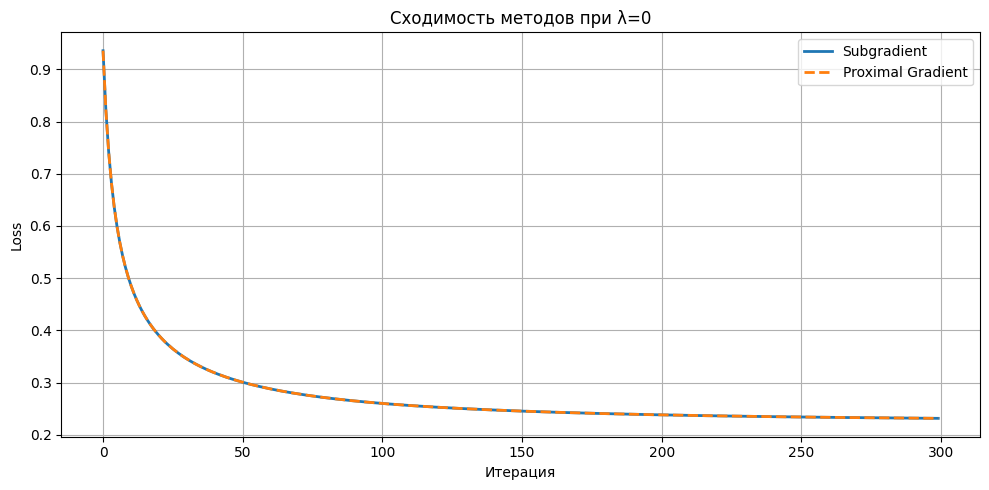

--- Финальные результаты ---
Subgradient sparsity: 0.00%
Proximal sparsity:    0.00%


In [23]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import OneHotEncoder

X, y = make_classification(n_samples=300, n_features=10, n_informative=6,
                           n_classes=3, n_clusters_per_class=1, random_state=42)
c, d = 3, X.shape[1]
N = X.shape[0]

enc = OneHotEncoder(sparse_output=False)
y_onehot = enc.fit_transform(y.reshape(-1, 1))

def softmax(z):
    z -= np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(W, X, y_onehot):
    logits = X @ W.T
    probs = softmax(logits)
    return -np.sum(y_onehot * np.log(probs + 1e-12)) / X.shape[0]

def sparsity(W):
    return np.mean(np.abs(W) < 1e-6)

# 2. Subgradient Descent

def subgradient_softmax(X, y_onehot, lr=0.1, max_iter=300):
    W = np.zeros((c, d))
    losses = []
    for i in range(max_iter):
        logits = X @ W.T
        probs = softmax(logits)
        grad = (probs - y_onehot).T @ X / X.shape[0]
        W -= lr * grad
        loss = compute_loss(W, X, y_onehot)
        losses.append(loss)
    return W, losses

# 3. Proximal Gradient Descent (with λ = 0)

def prox_softmax(X, y_onehot, lr=0.1, max_iter=300):
    W = np.zeros((c, d))
    losses = []
    for i in range(max_iter):
        logits = X @ W.T
        probs = softmax(logits)
        grad = (probs - y_onehot).T @ X / X.shape[0]
        W -= lr * grad
        loss = compute_loss(W, X, y_onehot)
        losses.append(loss)
    return W, losses

# learning rate
W_sub, loss_sub = subgradient_softmax(X, y_onehot, lr=0.1)
W_prox, loss_prox = prox_softmax(X, y_onehot, lr=0.1)

plt.figure(figsize=(10, 5))
plt.plot(loss_sub, label='Subgradient', lw=2)
plt.plot(loss_prox, label='Proximal Gradient', lw=2, linestyle='--')
plt.xlabel('Итерация')
plt.ylabel('Loss')
plt.title('Сходимость методов при λ=0')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("--- Финальные результаты ---")
print(f"Subgradient sparsity: {sparsity(W_sub)*100:.2f}%")
print(f"Proximal sparsity:    {sparsity(W_prox)*100:.2f}%")


Методы эквивалентны при $\lambda = 0$:
Поскольку в постановке задачи проксимальный шаг применяется к L1-регуляризатору, а при
$\lambda = 0$ он отсутствует, проксимальный оператор становится тождественным отображением

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X, y = make_classification(n_samples=300, n_features=10, n_informative=6,
                           n_classes=3, n_clusters_per_class=1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
c, d = 3, X.shape[1]

enc = OneHotEncoder(sparse_output=False)
y_train_onehot = enc.fit_transform(y_train.reshape(-1, 1))

def softmax(z):
    z -= np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def compute_loss(W, X, y_onehot, lam):
    logits = X @ W.T
    probs = softmax(logits)
    data_loss = -np.sum(y_onehot * np.log(probs + 1e-12)) / X.shape[0]
    reg = lam * np.sum(np.abs(W))
    return data_loss + reg

def sparsity(W):
    return np.mean(np.abs(W) < 1e-6)

def predict(W, X):
    logits = X @ W.T
    probs = softmax(logits)
    return np.argmax(probs, axis=1)

# Субградиентный спуск

def subgradient_softmax(X, y_onehot, lam=0.1, lr=0.1, max_iter=300, tol=1e-2):
    W = np.zeros((c, d))
    losses = []
    for i in range(max_iter):
        logits = X @ W.T
        probs = softmax(logits)
        grad = (probs - y_onehot).T @ X / X.shape[0] + lam * np.sign(W)
        W -= lr * grad
        loss = compute_loss(W, X, y_onehot, lam)
        losses.append(loss)
        if i > 1 and abs(losses[-2] - loss) < tol:
            break
    return W, losses

# Проксимальный градиентный метод

def prox_softmax_l1(X, y_onehot, lam=0.1, lr=0.1, max_iter=300, tol=1e-2):
    W = np.zeros((c, d))
    losses = []
    for i in range(max_iter):
        logits = X @ W.T
        probs = softmax(logits)
        grad = (probs - y_onehot).T @ X / X.shape[0]
        W_temp = W - lr * grad
        W = np.sign(W_temp) * np.maximum(np.abs(W_temp) - lr * lam, 0.0)
        loss = compute_loss(W, X, y_onehot, lam)
        losses.append(loss)
        if i > 1 and abs(losses[-2] - loss) < tol:
            break
    return W, losses

# (method, func, lr, tol, λ)
configs = [
    ("Subgradient Descent", subgradient_softmax, 1e-1, 1e-2, 0.01),
    ("Subgradient Descent", subgradient_softmax, 1e-2, 1e-2, 0.01),
    ("Subgradient Descent", subgradient_softmax, 1e-3, 1e-2, 0.01),
    ("Subgradient Descent", subgradient_softmax, 1e-4, 1e-2, 0.01),
    ("Subgradient Descent", subgradient_softmax, 1e-5, 1e-2, 0.01),
    ("Proximal Gradient Descent", prox_softmax_l1, 1e-1, 1e-2, 0.01),
    ("Proximal Gradient Descent", prox_softmax_l1, 1e-2, 1e-2, 0.01),
    ("Proximal Gradient Descent", prox_softmax_l1, 1e-3, 1e-2, 0.01),
    ("Proximal Gradient Descent", prox_softmax_l1, 1e-4, 1e-2, 0.01),
    ("Proximal Gradient Descent", prox_softmax_l1, 1e-5, 1e-2, 0.01),
    ("Subgradient Descent", subgradient_softmax, 1e-2, 1e-3, 0.01),
    ("Proximal Gradient Descent", prox_softmax_l1, 1e-2, 1e-3, 0.01),
    ("Subgradient Descent", subgradient_softmax, 1e-2, 1e-1, 0.01),
    ("Proximal Gradient Descent", prox_softmax_l1, 1e-2, 1e-1, 0.01),
    ("Subgradient Descent", subgradient_softmax, 1e-2, 1, 0.01),
    ("Proximal Gradient Descent", prox_softmax_l1, 1e-2, 1, 0.01),
]

print("\nТаблица сравнения методов:")
print("Method\t\t\tLR\tTol\tIter\tSparsity\tλ\tTest Acc")

for method_name, method, lr, tol, lam in configs:
    W, loss_hist = method(X_train, y_train_onehot, lam=lam, lr=lr, tol=tol)
    y_pred = predict(W, X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{method_name:<24} {lr:.0e}\t{tol:.0e}\t{len(loss_hist)}\t{sparsity(W)*100:.2f}%\t{lam:.3f}\t{acc:.2f}")


Таблица сравнения методов:
Method			LR	Tol	Iter	Sparsity	λ	Test Acc
Subgradient Descent      1e-01	1e-02	14	0.00%	0.010	0.92
Subgradient Descent      1e-02	1e-02	16	0.00%	0.010	0.84
Subgradient Descent      1e-03	1e-02	3	0.00%	0.010	0.84
Subgradient Descent      1e-04	1e-02	3	6.67%	0.010	0.84
Subgradient Descent      1e-05	1e-02	3	23.33%	0.010	0.84
Proximal Gradient Descent 1e-01	1e-02	14	23.33%	0.010	0.92
Proximal Gradient Descent 1e-02	1e-02	16	6.67%	0.010	0.84
Proximal Gradient Descent 1e-03	1e-02	3	6.67%	0.010	0.84
Proximal Gradient Descent 1e-04	1e-02	3	10.00%	0.010	0.84
Proximal Gradient Descent 1e-05	1e-02	3	30.00%	0.010	0.84
Subgradient Descent      1e-02	1e-03	138	0.00%	0.010	0.92
Proximal Gradient Descent 1e-02	1e-03	138	23.33%	0.010	0.92
Subgradient Descent      1e-02	1e-01	3	0.00%	0.010	0.84
Proximal Gradient Descent 1e-02	1e-01	3	6.67%	0.010	0.84
Subgradient Descent      1e-02	1e+00	3	0.00%	0.010	0.84
Proximal Gradient Descent 1e-02	1e+00	3	6.67%	0.010	0.84
